<a href="https://colab.research.google.com/github/bhagyoday-j/ML-Assignments/blob/main/TY-open-elective/Assingments/9_MNIST_handwritten_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 9**

andwritten Digit Recognition using Support Vector Machine (SVM) - Train an SVM classifier on the MNIST dataset to recognize handwritten
digits (0-9). Perform hyperparameter tuning (kernel type, C value) and
evaluate performance using precision and recall

In [1]:
# Cell 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape :", X_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nNumber of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape : (10000, 28, 28)
Testing labels shape: (10000,)

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


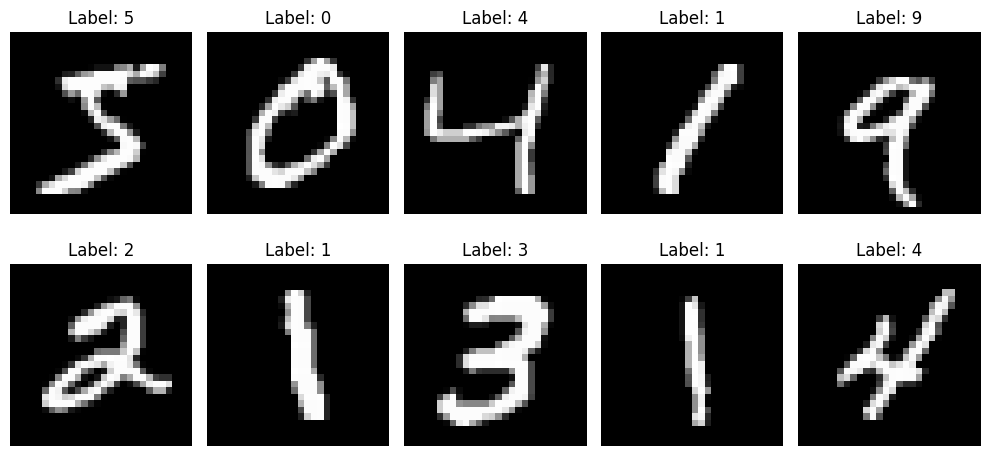

In [3]:
# Cell 3: Visualize Sample Images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Pixel value range:
Minimum: 0
Maximum: 255

Class distribution:
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


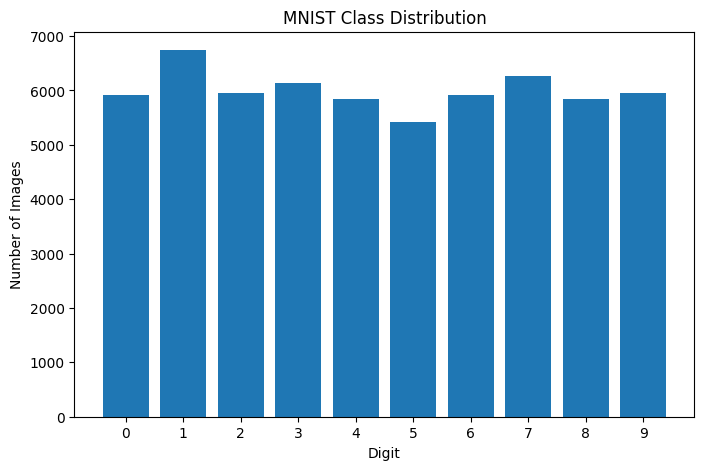

In [4]:
# Cell 4: Explore Dataset

print("Pixel value range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nClass distribution:")
class_counts = pd.Series(y_train).value_counts().sort_index()

print(class_counts)

# Plot class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Class Distribution")
plt.xticks(range(10))
plt.show()

In [5]:
# Cell 5: Preprocess Data for SVM

# Flatten 28x28 images into 784 features
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values from 0-255 to 0-1
X_train_scaled = X_train_flat / 255.0
X_test_scaled = X_test_flat / 255.0

print("Original image shape :", X_train.shape)
print("After flattening     :", X_train_flat.shape)
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

print("\nScaled pixel range:")
print("Minimum:", X_train_scaled.min())
print("Maximum:", X_train_scaled.max())

Original image shape : (60000, 28, 28)
After flattening     : (60000, 784)
Scaled training shape: (60000, 784)
Scaled testing shape : (10000, 784)

Scaled pixel range:
Minimum: 0.0
Maximum: 1.0


In [6]:
# Cell 6: Create a Smaller Dataset for Hyperparameter Tuning

from sklearn.model_selection import train_test_split

# Use 10,000 samples for faster hyperparameter tuning
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=10000,
    random_state=42,
    stratify=y_train
)

print("Tuning dataset shape:", X_tune.shape)
print("Tuning labels shape :", y_tune.shape)

print("\nClass distribution in tuning dataset:")
print(pd.Series(y_tune).value_counts().sort_index())

Tuning dataset shape: (10000, 784)
Tuning labels shape : (10000,)

Class distribution in tuning dataset:
0     987
1    1124
2     993
3    1022
4     974
5     904
6     986
7    1044
8     975
9     991
Name: count, dtype: int64


In [7]:
# Cell 7: Train Baseline SVM

print("Training baseline SVM...")

baseline_svm = SVC(
    kernel="rbf",
    C=1.0
)

baseline_svm.fit(X_tune, y_tune)

print("Baseline SVM training completed!")

Training baseline SVM...
Baseline SVM training completed!


In [8]:
# Cell 8: Evaluate Baseline SVM

print("Making predictions...")

y_pred_baseline = baseline_svm.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, average="weighted")
recall = recall_score(y_test, y_pred_baseline, average="weighted")
f1 = f1_score(y_test, y_pred_baseline, average="weighted")

print("\n===== BASELINE SVM RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_baseline))

Making predictions...

===== BASELINE SVM RESULTS =====
Accuracy  : 0.9635
Precision : 0.9635
Recall    : 0.9635
F1-Score  : 0.9635

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.96      0.96      1032
           3       0.94      0.96      0.95      1010
           4       0.95      0.96      0.96       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.98       958
           7       0.96      0.95      0.96      1028
           8       0.96      0.95      0.95       974
           9       0.95      0.93      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [9]:
# Cell 9: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Define parameters to test
param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10]
}

# Create SVM model
svm = SVC()

# Grid Search
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

print("Starting hyperparameter tuning...")

grid_search.fit(X_tune, y_tune)

print("\nHyperparameter tuning completed!")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search.best_score_:.4f}")

Starting hyperparameter tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Hyperparameter tuning completed!

Best Parameters:
{'C': 10, 'kernel': 'rbf'}

Best Cross-Validation F1 Score:
0.9599


In [10]:
# Cell 10: Compare Hyperparameter Tuning Results

results = pd.DataFrame(grid_search.cv_results_)

comparison = results[
    [
        "param_kernel",
        "param_C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

comparison.columns = [
    "Kernel",
    "C",
    "Mean F1 Score",
    "Std F1 Score",
    "Rank"
]

comparison = comparison.sort_values("Rank")

print("===== HYPERPARAMETER COMPARISON =====")
print(comparison.to_string(index=False))

===== HYPERPARAMETER COMPARISON =====
Kernel    C  Mean F1 Score  Std F1 Score  Rank
   rbf 10.0       0.959948      0.001211     1
   rbf  1.0       0.955012      0.000603     2
linear  0.1       0.921304      0.001506     3
   rbf  0.1       0.916706      0.002868     4
linear  1.0       0.906307      0.003243     5
linear 10.0       0.904159      0.002515     6


In [11]:
# Cell 11: Train Best SVM Model

best_svm = SVC(
    kernel=grid_search.best_params_["kernel"],
    C=grid_search.best_params_["C"]
)

print("Training best SVM model...")
best_svm.fit(X_tune, y_tune)

print("Best SVM training completed!")
print("\nBest Parameters:", grid_search.best_params_)

Training best SVM model...
Best SVM training completed!

Best Parameters: {'C': 10, 'kernel': 'rbf'}


In [12]:
# Cell 12: Evaluate Best SVM Model

print("Making predictions with the tuned SVM...")

y_pred = best_svm.predict(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n===== FINAL SVM RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

Making predictions with the tuned SVM...

===== FINAL SVM RESULTS =====
Accuracy  : 0.9692
Precision : 0.9693
Recall    : 0.9692
F1-Score  : 0.9692

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.95      0.97      0.96      1010
           4       0.96      0.97      0.96       982
           5       0.98      0.95      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.97      0.96      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



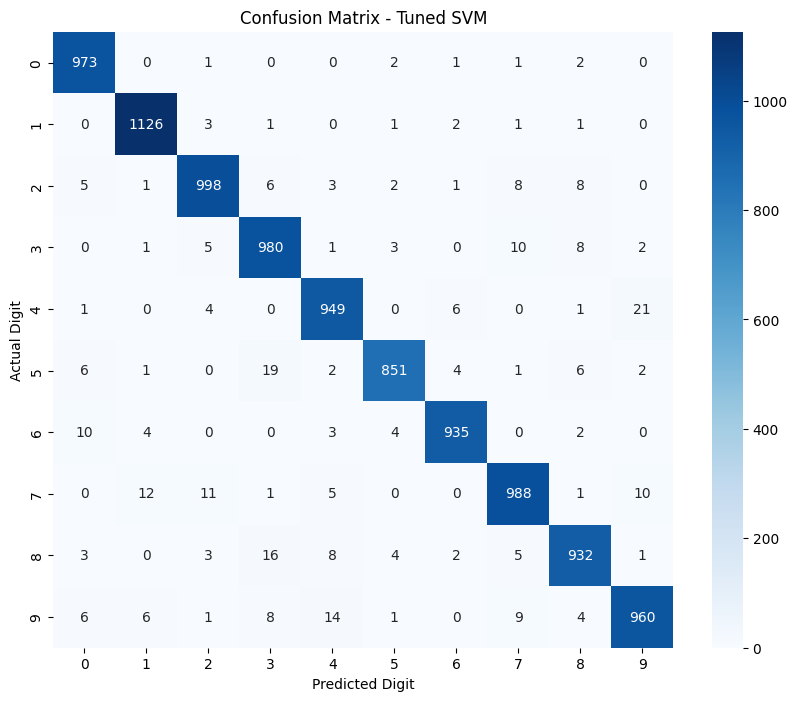

In [13]:
# Cell 13: Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix - Tuned SVM")
plt.show()

Correct predictions  : 9692
Incorrect predictions: 308


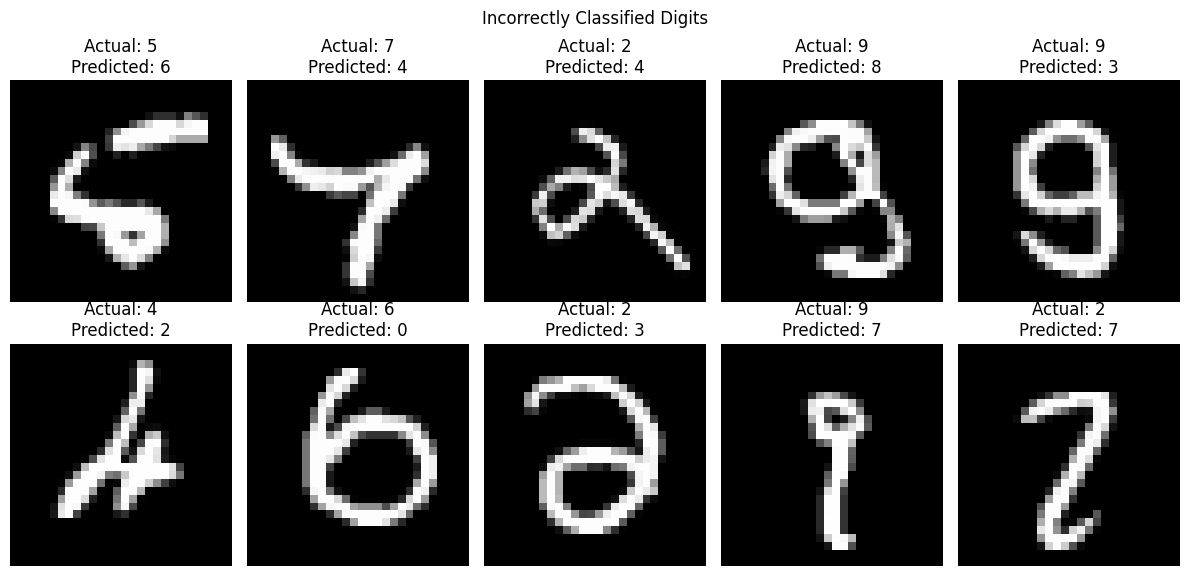

In [14]:
# Cell 14: Visualize Correct and Incorrect Predictions

# Find correct and incorrect predictions
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

print("Correct predictions  :", len(correct_indices))
print("Incorrect predictions:", len(incorrect_indices))

# Plot incorrect predictions
plt.figure(figsize=(12, 6))

for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Actual: {y_test[idx]}\nPredicted: {y_pred[idx]}")
    plt.axis("off")

plt.suptitle("Incorrectly Classified Digits")
plt.tight_layout()
plt.show()

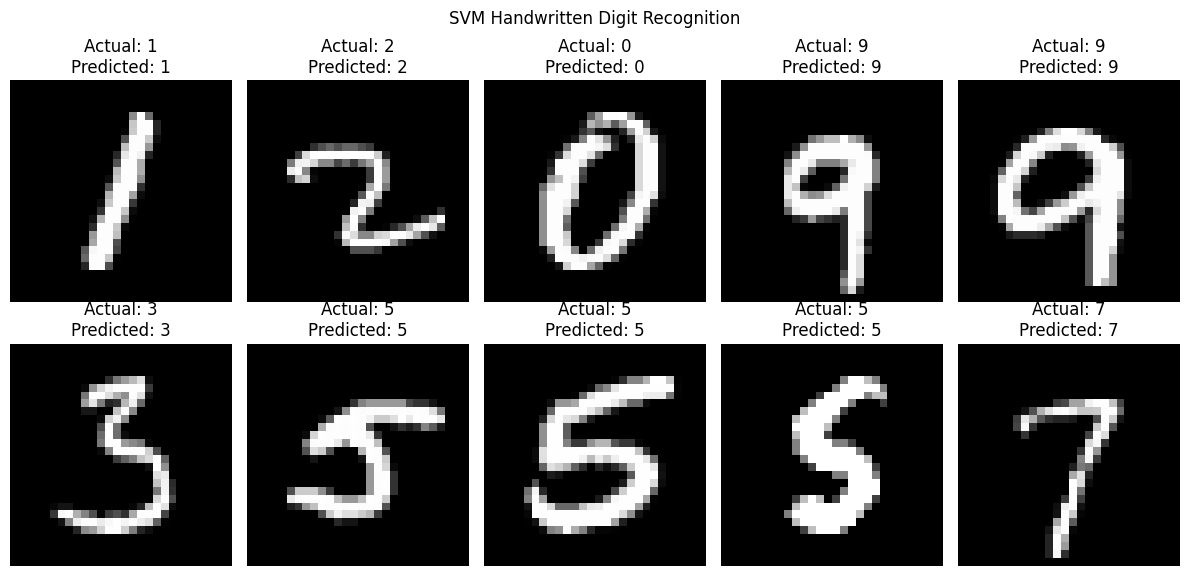

In [15]:
# Cell 15: Random Prediction Demo

import random

# Select 10 random test images
random_indices = random.sample(range(len(X_test)), 10)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[idx], cmap="gray")

    actual = y_test[idx]
    predicted = y_pred[idx]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.suptitle("SVM Handwritten Digit Recognition")
plt.tight_layout()
plt.show()

In [16]:
# Cell 16: Compare Baseline and Tuned SVM

baseline_results = {
    "Model": "Baseline SVM (RBF, C=1)",
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline, average="weighted"),
    "Recall": recall_score(y_test, y_pred_baseline, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred_baseline, average="weighted")
}

tuned_results = {
    "Model": "Tuned SVM (RBF, C=10)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred, average="weighted")
}

final_comparison = pd.DataFrame([
    baseline_results,
    tuned_results
])

print("===== FINAL MODEL COMPARISON =====")
print(final_comparison.to_string(index=False))

print("\n===== IMPROVEMENT =====")
print(
    f"Accuracy improvement: "
    f"{(tuned_results['Accuracy'] - baseline_results['Accuracy']) * 100:.2f}%"
)

===== FINAL MODEL COMPARISON =====
                  Model  Accuracy  Precision  Recall  F1-Score
Baseline SVM (RBF, C=1)    0.9635   0.963511  0.9635  0.963456
  Tuned SVM (RBF, C=10)    0.9692   0.969254  0.9692  0.969172

===== IMPROVEMENT =====
Accuracy improvement: 0.57%


Upload a handwritten digit image (0-9):


Saving 1.png to 1.png


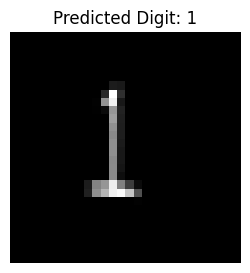

Predicted Digit: 1


In [19]:
# Cell 17: Accept Image from User and Predict Digit

from google.colab import files
from PIL import Image
import io

print("Upload a handwritten digit image (0-9):")

uploaded = files.upload()

# Get uploaded file
file_name = list(uploaded.keys())[0]

# Open image
image = Image.open(io.BytesIO(uploaded[file_name])).convert("L")

# Resize to MNIST size
image = image.resize((28, 28))

# Convert image to numpy array
image_array = np.array(image)

# MNIST uses white digit on black background
# If uploaded image has black digit on white background, invert it
if image_array.mean() > 127:
    image_array = 255 - image_array

# Normalize
image_scaled = image_array / 255.0

# Flatten 28x28 -> 784
image_input = image_scaled.reshape(1, -1)

# Predict
prediction = best_svm.predict(image_input)[0]

# Display image and prediction
plt.figure(figsize=(3, 3))
plt.imshow(image_array, cmap="gray")
plt.title(f"Predicted Digit: {prediction}")
plt.axis("off")
plt.show()

print("Predicted Digit:", prediction)